Q1            : 2.0
Q3            : 3.7
IQR           : 1.7000000000000002
Lower Bound   : -0.5500000000000003
Upper Bound   : 6.25
Outlier Count : 85


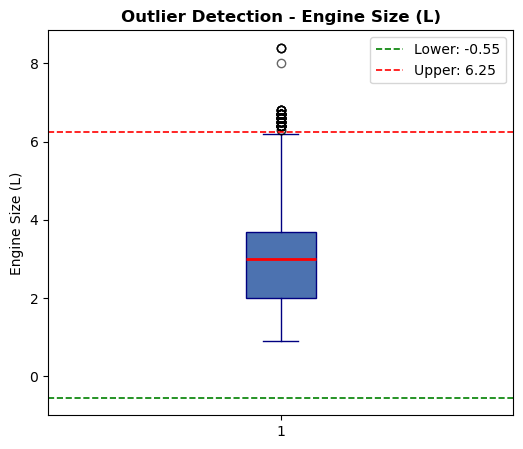

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your cleaned dataset
emissions = pd.read_csv("emissions_cleaned (2).csv")

df=emissions[['Engine_size_L', 'Cylinders', 'Fuel_type','CO2_emissions_g_per_km']]

import matplotlib.pyplot as plt
import numpy as np

# IQR Calculation
Q1 = df['Engine_size_L'].quantile(0.25)
Q3 = df['Engine_size_L'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Engine_size_L'] < lower) | (df['Engine_size_L'] > upper)]

print(f"Q1            : {Q1}")
print(f"Q3            : {Q3}")
print(f"IQR           : {IQR}")
print(f"Lower Bound   : {lower}")
print(f"Upper Bound   : {upper}")
print(f"Outlier Count : {len(outliers)}")

# Box Plot
plt.figure(figsize=(6, 5))
plt.boxplot(df['Engine_size_L'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='#4C72B0', color='navy'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', color='orange', markersize=6, alpha=0.6),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'))

plt.axhline(lower, color='green', linestyle='--', linewidth=1.2, label=f'Lower: {lower:.2f}')
plt.axhline(upper, color='red',   linestyle='--', linewidth=1.2, label=f'Upper: {upper:.2f}')

plt.title('Outlier Detection - Engine Size (L)', fontweight='bold')
plt.ylabel('Engine Size (L)')
plt.legend()
plt.show()

In [10]:
# Remove outliers from Engine_size_L
Q1 = df['Engine_size_L'].quantile(0.25)
Q3 = df['Engine_size_L'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Before: {len(df)} rows")

df1 = df[(df['Engine_size_L'] >= lower) & (df['Engine_size_L'] <= upper)]

print(f"After : {len(df1)} rows")
print(f"Removed: {len(df) - len(df1)} rows")

Before: 5214 rows
After : 5129 rows
Removed: 85 rows


In [11]:
df1.head()

,Engine_size_L,Cylinders,Fuel_type,CO2_emissions_g_per_km
0,2.0,4,premium_gasoline,196
1,2.4,4,premium_gasoline,221
2,1.5,4,premium_gasoline,136
3,3.5,6,premium_gasoline,255
4,3.5,6,premium_gasoline,244


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ct = ColumnTransformer(transformers=[("encoder", OneHotEncoder(), ['Fuel_type'])], 
                       remainder="passthrough")

ct.fit(df1)

# Get all feature names automatically
feature_names = ct.get_feature_names_out()

# Clean up the names (removes "encoder__" and "remainder__" prefixes)
feature_names = [name.replace("encoder__", "").replace("remainder__", "") 
                 for name in feature_names]

dataset = pd.DataFrame(ct.transform(df1), columns=feature_names)


In [13]:
dataset.head()

,Fuel_type_diesel,Fuel_type_ethanol,Fuel_type_natural_gas,Fuel_type_premium_gasoline,Fuel_type_regular_gasoline,Engine_size_L,Cylinders,CO2_emissions_g_per_km
0,0.0,0.0,0.0,1.0,0.0,2.0,4.0,196.0
1,0.0,0.0,0.0,1.0,0.0,2.4,4.0,221.0
2,0.0,0.0,0.0,1.0,0.0,1.5,4.0,136.0
3,0.0,0.0,0.0,1.0,0.0,3.5,6.0,255.0
4,0.0,0.0,0.0,1.0,0.0,3.5,6.0,244.0


In [17]:
dataset.to_csv('processed_emissions3.csv', index=False)

In [16]:
dataset.shape

(5129, 8)